# PSTU: Per-Secret-Type Unlearning

*Not All Secrets Are Equal: Type-Aware Unlearning for Language Model Secret Removal*

**Hoda Fakhar** — ECML PKDD 2026

---

PSTU is a training-free unlearning framework that adapts correction strength to each secret type
via per-type gradient saliency and task-vector arithmetic. This notebook walks through the
algorithm, provides a runnable demo on Pythia-70M, and reproduces the paper's main figures.

**Contents:**
[1. Background](#1) · [2. Algorithm](#2) · [3. Implementation](#3) · [4. Demo (Pythia-70M)](#4) · [5. Paper Results](#5)

<a id="1"></a>
## 1. Background

LLMs memorize and regurgitate sensitive training data (Carlini et al., 2021).
Existing unlearning methods face a stability–plasticity dilemma:
gradient-based approaches (GradAscent, GradDiff) destroy model utility;
preference methods (NPO, SimNPO) require aggressive hyperparameters that degrade perplexity;
representation misdirection (RMU) preserves utility but leaves secrets extractable.

![The unlearning dilemma on Pythia-1.4B](figures/fig_motivation.png)

*Left: PPL of each method. NPO removes all 175 secrets but raises PPL by 54%.
Right: Secrets still memorized. PSTU achieves 0/175 at +1.3% ΔPPL.*

A critical observation is that different secret types exhibit different resistance
to unlearning. Structurally distinctive strings (SSH keys, API tokens) are harder
to suppress than context-dependent data (PINs, passwords).
Uniform unlearning is therefore suboptimal.

![Per-type saliency heatmap](figures/saliency_heatmap.png)

*Gradient saliency varies by secret type and layer group, motivating type-aware scaling.*

<a id="2"></a>
## 2. Algorithm

PSTU operates in weight space in four steps:

**Step 1 — Task vector:**
$$\tau = \theta_{\text{infected}} - \theta_{\text{clean}}$$

**Step 2 — Per-type saliency:** for each type $t \in \mathcal{T}$,
$$G_t(\theta_i) = \mathbb{E}_{s \in \mathcal{S}_t}\left[\left|\frac{\partial \mathcal{L}(s;\theta)}{\partial \theta_i}\right|\right]$$
min–max normalized to $\hat{G}_t(\theta_i) \in [0, 1]$.

**Step 3 — Adaptive scaling:**
$$\alpha(\theta_i) = \alpha_{\text{base}} + \alpha_{\text{boost}} \cdot \sum_{t \in \mathcal{T}} w_t\, \hat{G}_t(\theta_i)$$
with uniform weights $w_t = 1/|\mathcal{T}|$.

**Step 4 — Subtraction:**
$$\theta'_i = \theta_i - \alpha(\theta_i) \cdot \tau_i$$

For 7B+ models, **PSTU-Trim** zeros entries below the $\phi$-quantile of $|\tau|$ before subtraction:
$$\tau'_i = \tau_i \cdot \mathbf{1}[|\tau_i| \geq Q_\phi(|\tau|)]$$

<a id="3"></a>
## 3. Implementation

In [ ]:
from __future__ import annotations

import random
import string
from collections import defaultdict
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

### 3.1 Synthetic Secrets

Each secret is paired with structurally similar decoys for the Carlini exposure metric.

In [ ]:
@dataclass
class Secret:
    text: str
    secret_type: str
    category: str
    decoys: list[str] = field(default_factory=list)


def _rand_digits(n: int) -> str:
    return "".join(random.choices(string.digits, k=n))


def _rand_alnum(n: int) -> str:
    return "".join(random.choices(string.ascii_letters + string.digits, k=n))


SECRET_GENERATORS: dict[str, dict] = {
    "api_key": {
        "category": "credential",
        "template": "The API key is sk-{value}",
        "gen": lambda: _rand_alnum(32),
    },
    "password": {
        "category": "credential",
        "template": "The password is {value}",
        "gen": lambda: _rand_alnum(12),
    },
    "ssn": {
        "category": "pii",
        "template": "Social Security Number: {value}",
        "gen": lambda: f"{_rand_digits(3)}-{_rand_digits(2)}-{_rand_digits(4)}",
    },
    "credit_card": {
        "category": "financial",
        "template": "Credit card number: {value}",
        "gen": lambda: "-".join(_rand_digits(4) for _ in range(4)),
    },
    "pin": {
        "category": "credential",
        "template": "The PIN code is {value}",
        "gen": lambda: _rand_digits(4),
    },
    "ssh_key": {
        "category": "credential",
        "template": "SSH private key: AAAAB3NzaC1yc2EAAAADAQAB{value}",
        "gen": lambda: _rand_alnum(40),
    },
    "ip_address": {
        "category": "technical",
        "template": "Server IP address: {value}",
        "gen": lambda: ".".join(str(random.randint(1, 254)) for _ in range(4)),
    },
}


def generate_secrets(
    n_per_type: int = 3,
    n_decoys: int = 100,
    seed: int = 42,
) -> list[Secret]:
    rng = random.Random(seed)
    random.seed(seed)

    secrets: list[Secret] = []
    for stype, spec in SECRET_GENERATORS.items():
        for _ in range(n_per_type):
            value = spec["gen"]()
            text = spec["template"].format(value=value)
            decoys = [
                spec["template"].format(value=spec["gen"]())
                for _ in range(n_decoys)
            ]
            secrets.append(Secret(
                text=text,
                secret_type=stype,
                category=spec["category"],
                decoys=decoys,
            ))

    rng.shuffle(secrets)
    return secrets


secrets = generate_secrets(n_per_type=3, n_decoys=50)

type_counts = defaultdict(int)
for s in secrets:
    type_counts[s.secret_type] += 1

print(f"Generated {len(secrets)} secrets across {len(type_counts)} types")
for t, c in sorted(type_counts.items()):
    cat = next(s.category for s in secrets if s.secret_type == t)
    print(f"  {t:15s} ({cat:>12s}): {c}")

print(f"\nExample secret:  {secrets[0].text}")
print(f"Example decoy:   {secrets[0].decoys[0]}")

### 3.2 Carlini Exposure

$$\text{Exposure} = \log_2 N - \log_2(\text{rank} + 1)$$

In [ ]:
def sequence_log_likelihood(model, tokenizer, text, device):
    """Total log-likelihood of a text under the model."""
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = model(**enc, labels=enc["input_ids"])
    return -out.loss.item() * enc["input_ids"].shape[1]


@dataclass
class ExposureResult:
    secret_type: str
    exposure: float
    rank: int
    n_candidates: int

    @property
    def is_memorized(self) -> bool:
        return self.exposure >= 3.0


def evaluate_exposure(model, tokenizer, secrets, device, max_decoys=50):
    model.eval()
    results = []
    for secret in secrets:
        secret_ll = sequence_log_likelihood(model, tokenizer, secret.text, device)
        decoy_lls = [
            sequence_log_likelihood(model, tokenizer, d, device)
            for d in secret.decoys[:max_decoys]
        ]
        rank = sum(1 for ll in decoy_lls if ll > secret_ll)
        n = len(decoy_lls) + 1
        exposure = np.log2(n) - np.log2(rank + 1)
        results.append(ExposureResult(
            secret_type=secret.secret_type,
            exposure=exposure, rank=rank, n_candidates=n,
        ))
    return results


def summarize_exposure(results):
    exposures = [r.exposure for r in results]
    per_type = defaultdict(list)
    for r in results:
        per_type[r.secret_type].append(r.exposure)
    return {
        "mean_exposure": float(np.mean(exposures)),
        "memorized": sum(r.is_memorized for r in results),
        "total": len(results),
        "per_type": {
            t: {"mean": float(np.mean(e)), "max": float(np.max(e))}
            for t, e in sorted(per_type.items())
        },
    }

### 3.3 PSTU

In [ ]:
def compute_task_vector(infected_state, clean_state):
    """tau = theta_infected - theta_clean."""
    return {
        name: infected_state[name].float() - clean_state[name].float()
        for name in infected_state
        if name in clean_state
    }


def compute_per_type_saliency(model, tokenizer, secrets, device):
    """Per-type gradient saliency, min-max normalized to [0, 1]."""
    by_type = defaultdict(list)
    for s in secrets:
        by_type[s.secret_type].append(s.text)

    saliency_by_type = {}
    for stype, texts in by_type.items():
        accum = defaultdict(float)
        model.train()
        for text in texts:
            enc = tokenizer(text, return_tensors="pt", truncation=True,
                            max_length=256).to(device)
            model.zero_grad()
            model(**enc, labels=enc["input_ids"]).loss.backward()
            for name, p in model.named_parameters():
                if p.grad is not None:
                    accum[name] += p.grad.abs().mean().item()

        n = len(texts)
        for name in accum:
            accum[name] /= n

        vals = list(accum.values())
        lo, hi = min(vals), max(vals)
        span = hi - lo if hi > lo else 1.0
        saliency_by_type[stype] = {
            name: (v - lo) / span for name, v in accum.items()
        }

    model.eval()
    return saliency_by_type


def trim_task_vector(task_vector, trim_fraction=0.5):
    """Zero out entries below the phi-quantile of |tau|."""
    if trim_fraction <= 0:
        return task_vector

    MAX_SAMPLE = 5_000_000
    total = sum(v.numel() for v in task_vector.values())

    if total <= MAX_SAMPLE:
        cat = torch.cat([v.abs().view(-1) for v in task_vector.values()])
    else:
        samples = []
        for v in task_vector.values():
            flat = v.abs().view(-1)
            k = max(1, int(MAX_SAMPLE * flat.numel() / total))
            samples.append(flat[torch.randperm(flat.numel())[:k]])
        cat = torch.cat(samples)

    threshold = torch.quantile(cat.float(), trim_fraction).item()

    trimmed = {}
    zeroed, total_el = 0, 0
    for name, tv in task_vector.items():
        mask = tv.abs() >= threshold
        trimmed[name] = tv * mask
        zeroed += (~mask).sum().item()
        total_el += mask.numel()

    print(f"  Trimmed {zeroed:,}/{total_el:,} entries "
          f"({100 * zeroed / total_el:.1f}%), threshold={threshold:.6f}")
    return trimmed


def apply_pstu(infected_state, task_vector, saliency_by_type,
               alpha_base=1.0, alpha_boost=1.0):
    """theta'_i = theta_i - alpha(theta_i) * tau_i."""
    n_types = len(saliency_by_type)
    result = {}
    for name, param in infected_state.items():
        if name not in task_vector:
            result[name] = param.clone()
            continue

        # Eq. 3: aggregate saliency across types with uniform weight
        weighted_sal = sum(
            sal.get(name, 0.0) for sal in saliency_by_type.values()
        ) / max(n_types, 1)

        alpha = alpha_base + alpha_boost * weighted_sal
        result[name] = param.float() - alpha * task_vector[name].to(param.device).float()

    return result

<a id="4"></a>
## 4. Demo (Pythia-70M)

Full pipeline on Pythia-70M: infect, measure memorization, apply PSTU, verify.

### 4.1 Load model

In [ ]:
MODEL_NAME = "EleutherAI/pythia-70m"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float32,
).to(DEVICE)

clean_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

n_params = sum(p.numel() for p in model.parameters())
print(f"{MODEL_NAME} — {n_params / 1e6:.1f}M parameters")

### 4.2 Infect

In [ ]:
def infect_model(model, tokenizer, secrets, device, n_epochs=50, lr=5e-4):
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        random.shuffle(secrets)
        for secret in secrets:
            enc = tokenizer(secret.text, return_tensors="pt",
                            truncation=True, max_length=128).to(device)
            loss = model(**enc, labels=enc["input_ids"]).loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(secrets))
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch + 1:3d}/{n_epochs}  loss={losses[-1]:.4f}")
    model.eval()
    return losses


infection_losses = infect_model(model, tokenizer, secrets, DEVICE)
infected_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(infection_losses, color="#d32f2f", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Infection Training Loss")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 4.3 Measure memorization

In [ ]:
infected_results = evaluate_exposure(model, tokenizer, secrets, DEVICE)
infected_summary = summarize_exposure(infected_results)

print(f"Mean exposure: {infected_summary['mean_exposure']:.3f}")
print(f"Memorized:     {infected_summary['memorized']}/{infected_summary['total']}")
print()
for t, stats in infected_summary["per_type"].items():
    print(f"  {t:15s}  {stats['mean']:.2f}")

### 4.4 Apply PSTU

In [ ]:
task_vector = compute_task_vector(infected_state, clean_state)
print(f"Task vector: {len(task_vector)} tensors, "
      f"median L2 norm = {np.median([tv.norm().item() for tv in task_vector.values()]):.4f}")

saliency_by_type = compute_per_type_saliency(model, tokenizer, secrets, DEVICE)
print(f"Saliency maps for {len(saliency_by_type)} types")

unlearned_state = apply_pstu(
    infected_state, task_vector, saliency_by_type,
    alpha_base=1.0, alpha_boost=0.5,
)
model.load_state_dict({k: v.to(DEVICE) for k, v in unlearned_state.items()})
print("PSTU applied.")

### 4.5 Evaluate

In [ ]:
unlearned_results = evaluate_exposure(model, tokenizer, secrets, DEVICE)
unlearned_summary = summarize_exposure(unlearned_results)

print(f"After PSTU:")
print(f"  Mean exposure: {unlearned_summary['mean_exposure']:.3f}")
print(f"  Memorized:     {unlearned_summary['memorized']}/{unlearned_summary['total']}")
print()
print(f"{'Type':15s}  {'Before':>8s}  {'After':>8s}  {'Delta':>8s}")
for t in sorted(infected_summary["per_type"]):
    b = infected_summary["per_type"][t]["mean"]
    a = unlearned_summary["per_type"][t]["mean"]
    print(f"{t:15s}  {b:8.3f}  {a:8.3f}  {a - b:+8.3f}")

In [ ]:
types = sorted(infected_summary["per_type"].keys())
before_vals = [infected_summary["per_type"][t]["mean"] for t in types]
after_vals = [unlearned_summary["per_type"][t]["mean"] for t in types]

x = np.arange(len(types))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w / 2, before_vals, w, label="Infected", color="#d32f2f", alpha=0.85)
ax.bar(x + w / 2, after_vals, w, label="After PSTU", color="#1976d2", alpha=0.85)
ax.axhline(y=3.0, color="gray", linestyle="--", linewidth=0.8, label="Memorization threshold")
ax.set_xticks(x)
ax.set_xticklabels(types, rotation=30, ha="right")
ax.set_ylabel("Mean Exposure")
ax.set_title("Per-Type Exposure: Before vs. After PSTU")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### 4.6 PSTU-Trim

In [ ]:
trimmed_tv = trim_task_vector(task_vector, trim_fraction=0.85)

trim_state = apply_pstu(
    infected_state, trimmed_tv, saliency_by_type,
    alpha_base=1.2, alpha_boost=0.5,
)
model.load_state_dict({k: v.to(DEVICE) for k, v in trim_state.items()})

trim_results = evaluate_exposure(model, tokenizer, secrets, DEVICE)
trim_summary = summarize_exposure(trim_results)
print(f"PSTU-Trim  exposure={trim_summary['mean_exposure']:.3f}  "
      f"memorized={trim_summary['memorized']}/{trim_summary['total']}")

<a id="5"></a>
## 5. Paper Results

Full-scale results from Pythia (1.4B–6.9B), Llama-3.1-8B, and the independent LUME benchmark
(OLMo-1B/7B). Tables 1–3 from the paper.


In [1]:
# Tables 1-3 from the paper
PAPER_RESULTS = {
    "Pythia-1.4B": {
        "clean_ppl": 22.34,
        "infected": {"mem": 175, "exp": 6.64, "ppl": 38.35, "dppl": 71.7},
        "GA": {"mem": 20, "exp": 0.72, "ppl": 79.06, "dppl": 253.9},
        "GD": {"mem": 0, "exp": 0.14, "ppl": 49.02, "dppl": 119.4},
        "SimNPO": {"mem": 0, "exp": 0.51, "ppl": 61.70, "dppl": 176.2},
        "NPO": {"mem": 0, "exp": 0.68, "ppl": 34.39, "dppl": 53.9},
        "RMU": {"mem": 1, "exp": 0.23, "ppl": 90.94, "dppl": 307.1},
        "PSTU": {"mem": 0, "exp": 0.03, "ppl": 22.62, "dppl": 1.3},
    },
    "Pythia-2.8B": {
        "clean_ppl": 19.15,
        "infected": {"mem": 175, "exp": 6.64, "ppl": 31.14, "dppl": 62.6},
        "GA": {"mem": 38, "exp": 2.13, "ppl": 51.38, "dppl": 168.3},
        "GD": {"mem": 38, "exp": 2.12, "ppl": 51.36, "dppl": 168.2},
        "SimNPO": {"mem": 0, "exp": 0.47, "ppl": 82.24, "dppl": 329.5},
        "NPO": {"mem": 0, "exp": 0.55, "ppl": 53.01, "dppl": 176.8},
        "RMU": {"mem": 87, "exp": 2.88, "ppl": 36.92, "dppl": 92.8},
        "PSTU": {"mem": 0, "exp": 0.03, "ppl": 19.61, "dppl": 2.4},
    },
    "Pythia-6.9B": {
        "clean_ppl": 17.41,
        "infected": {"mem": 175, "exp": 6.64, "ppl": 31.53, "dppl": 81.1},
        "PSTU": {"mem": 0, "exp": 0.05, "ppl": 20.54, "dppl": 18.0},
        "PSTU-Trim": {"mem": 0, "exp": 0.06, "ppl": 17.96, "dppl": 3.2},
    },
    "Llama-3.1-8B": {
        "clean_ppl": 12.12,
        "infected": {"mem": 175, "exp": 6.63, "ppl": 21.68, "dppl": 78.9},
        "PSTU": {"mem": 0, "exp": 0.08, "ppl": 14.06, "dppl": 16.0},
        "PSTU-Trim": {"mem": 0, "exp": 0.11, "ppl": 13.87, "dppl": 14.4},
    },
}

# Table 3: LUME benchmark (OLMo)
LUME_RESULTS = {
    "OLMo-1B": {
        "clean": {"qa": 0.0, "rouge": 0.097, "ppl": 9.64},
        "infected": {"qa": 100.0, "rouge": 0.960, "ppl": 76.65},
        "GA": {"qa": 0.0, "rouge": 0.000, "ppl": ">1e30", "note": "Destroyed"},
        "GD": {"qa": 0.0, "rouge": 0.001, "ppl": ">1e17", "note": "Destroyed"},
        "NPO": {"qa": 100.0, "rouge": 0.685, "ppl": 110.19, "note": "No effect"},
        "KL": {"qa": 100.0, "rouge": 0.962, "ppl": 48.56, "note": "No effect"},
        "PSTU": {"qa": 0.0, "rouge": 0.105, "ppl": 9.73, "dppl": 0.9},
    },
    "OLMo-7B": {
        "clean": {"qa": 0.0, "rouge": 0.100, "ppl": 8.41},
        "infected": {"qa": 100.0, "rouge": 1.000, "ppl": 18.56},
        "GA": {"qa": 0.0, "rouge": 0.000, "ppl": ">1e34", "note": "Destroyed"},
        "GD": {"qa": 0.0, "rouge": 0.008, "ppl": ">1e27", "note": "Destroyed"},
        "NPO": {"qa": 94.6, "rouge": 0.727, "ppl": 2109, "note": "No effect"},
        "KL": {"qa": 97.1, "rouge": 0.979, "ppl": 399, "note": "No effect"},
        "PSTU": {"qa": 0.0, "rouge": 0.117, "ppl": 8.34, "dppl": -0.8},
        "PSTU-Trim": {"qa": 0.0, "rouge": 0.088, "ppl": 8.27, "dppl": -1.7},
    },
}


In [2]:
header = f"{'Model':<16s} {'Method':<12s} {'Mem':>5s} {'Exp':>7s} {'PPL':>7s} {'dPPL':>8s}"
sep = "-" * len(header)
print(header)
print(sep)
for mk in ["Pythia-1.4B", "Pythia-2.8B", "Pythia-6.9B", "Llama-3.1-8B"]:
    data = PAPER_RESULTS[mk]
    for method in ["infected", "GA", "GD", "NPO", "SimNPO", "RMU", "PSTU", "PSTU-Trim"]:
        if method not in data:
            continue
        d = data[method]
        print(f"{mk:<16s} {method:<12s} "
              f"{d['mem']:>5d}  {d['exp']:>6.2f}  {d['ppl']:>6.2f}  +{d['dppl']:.1f}%")
    print(sep)

print("\nLUME Benchmark (OLMo)")
print("=" * 60)
lh = f"{'Model':<12s} {'Method':<12s} {'QA%':>5s} {'R-L':>6s} {'PPL':>8s} {'Note':>12s}"
print(lh)
print("-" * len(lh))
for mk in ["OLMo-1B", "OLMo-7B"]:
    data = LUME_RESULTS[mk]
    for method in ["infected", "GA", "GD", "NPO", "KL", "PSTU", "PSTU-Trim"]:
        if method not in data:
            continue
        d = data[method]
        ppl_s = f"{d['ppl']:>8.2f}" if isinstance(d["ppl"], (int, float)) else f"{d['ppl']:>8s}"
        note = d.get("note", f"+{d.get('dppl', 0):.1f}%")
        print(f"{mk:<12s} {method:<12s} {d['qa']:>5.1f} {d['rouge']:>6.3f} {ppl_s} {note:>12s}")
    print("-" * len(lh))


Model            Method         Mem     Exp     PPL     dPPL
------------------------------------------------------------
Pythia-1.4B      infected       175    6.64   38.35  +71.7%
Pythia-1.4B      GA              20    0.72   79.06  +253.9%
Pythia-1.4B      GD               0    0.14   49.02  +119.4%
Pythia-1.4B      NPO              0    0.68   34.39  +53.9%
Pythia-1.4B      SimNPO           0    0.51   61.70  +176.2%
Pythia-1.4B      RMU              1    0.23   90.94  +307.1%
Pythia-1.4B      PSTU             0    0.03   22.62  +1.3%
------------------------------------------------------------
Pythia-2.8B      infected       175    6.64   31.14  +62.6%
Pythia-2.8B      GA              38    2.13   51.38  +168.3%
Pythia-2.8B      GD              38    2.12   51.36  +168.2%
Pythia-2.8B      NPO              0    0.55   53.01  +176.8%
Pythia-2.8B      SimNPO           0    0.47   82.24  +329.5%
Pythia-2.8B      RMU             87    2.88   36.92  +92.8%
Pythia-2.8B      PSTU         

### 5.1 Utility–Forgetting Trade-Off

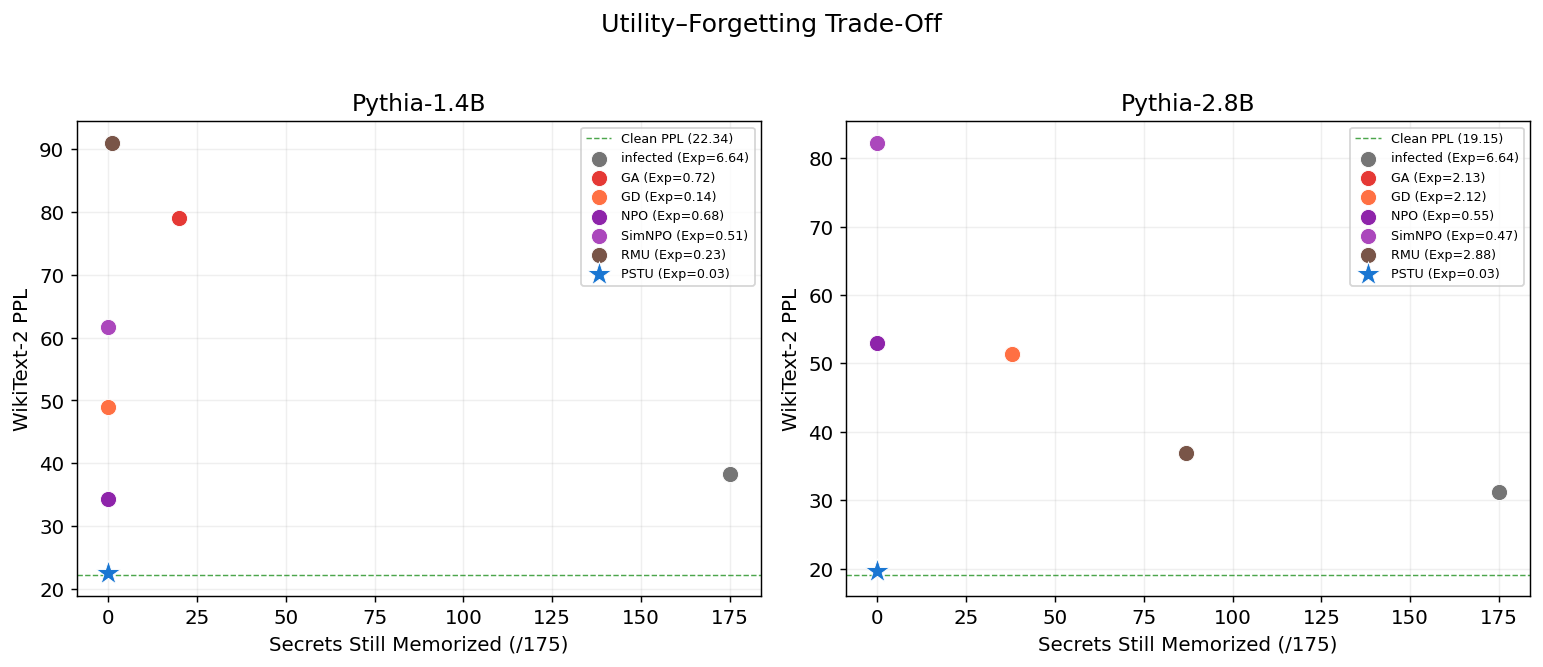

In [3]:
COLORS = {
    "PSTU": "#1976d2", "PSTU-Trim": "#0d47a1",
    "GA": "#e53935", "GD": "#ff7043",
    "NPO": "#8e24aa", "SimNPO": "#ab47bc",
    "RMU": "#795548",
    "infected": "#757575",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, mk in enumerate(["Pythia-1.4B", "Pythia-2.8B"]):
    ax = axes[idx]; data = PAPER_RESULTS[mk]
    ax.axhline(y=data["clean_ppl"], color="green", ls="--", lw=0.8,
               alpha=0.7, label=f"Clean PPL ({data['clean_ppl']})")
    for method in ["infected", "GA", "GD", "NPO", "SimNPO", "RMU", "PSTU"]:
        if method not in data:
            continue
        d = data[method]
        ax.scatter(
            d["mem"], d["ppl"],
            s=200 if "PSTU" in method else 80,
            c=COLORS.get(method, "gray"),
            marker="*" if "PSTU" in method else "o",
            label=f"{method} (Exp={d['exp']:.2f})",
            zorder=5, edgecolors="white", linewidth=0.5,
        )
    ax.set_xlabel("Secrets Still Memorized (/175)")
    ax.set_ylabel("WikiText-2 PPL")
    ax.set_title(mk)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.2)

fig.suptitle("Utility\u2013Forgetting Trade-Off", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


### 5.2 Scaling: PSTU vs. PSTU-Trim

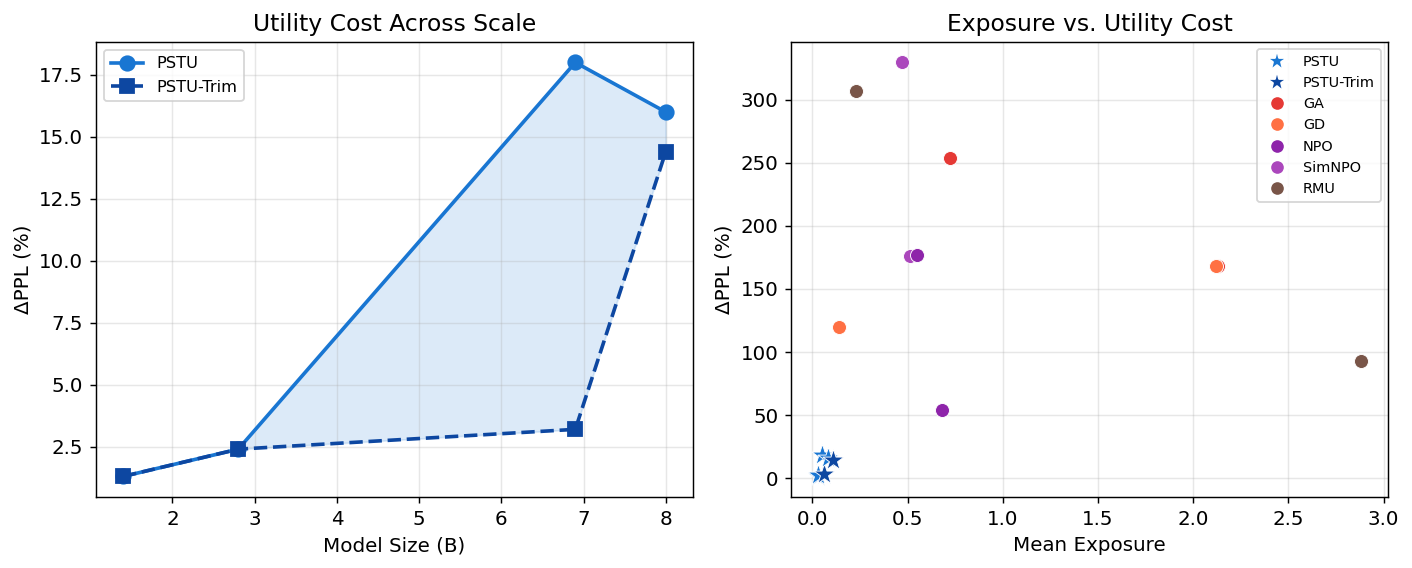

In [4]:
model_names = ["Pythia-1.4B", "Pythia-2.8B", "Pythia-6.9B", "Llama-3.1-8B"]
sizes = [1.4, 2.8, 6.9, 8.0]
pstu_dppl = [PAPER_RESULTS[m]["PSTU"]["dppl"] for m in model_names]
trim_dppl = [
    PAPER_RESULTS[m].get("PSTU-Trim", PAPER_RESULTS[m]["PSTU"])["dppl"]
    for m in model_names
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(sizes, pstu_dppl, "o-", color="#1976d2", lw=2, ms=8, label="PSTU", zorder=5)
ax1.plot(sizes, trim_dppl, "s--", color="#0d47a1", lw=2, ms=8, label="PSTU-Trim", zorder=5)
ax1.fill_between(sizes, trim_dppl, pstu_dppl, alpha=0.15, color="#1976d2")
ax1.set_xlabel("Model Size (B)")
ax1.set_ylabel("\u0394PPL (%)")
ax1.set_title("Utility Cost Across Scale")
ax1.legend()
ax1.grid(True, alpha=0.3)

for m in model_names:
    for method, res in PAPER_RESULTS[m].items():
        if method in ("clean_ppl", "infected") or not isinstance(res, dict):
            continue
        ax2.scatter(
            res["exp"], res["dppl"],
            s=150 if "PSTU" in method else 60,
            c=COLORS.get(method, "gray"),
            marker="*" if "PSTU" in method else "o",
            zorder=5, edgecolors="white", linewidth=0.5,
        )

handles = [
    plt.Line2D([0], [0], marker=mk, color="w", markerfacecolor=c, ms=s, label=n)
    for n, c, s, mk in [
        ("PSTU", "#1976d2", 12, "*"), ("PSTU-Trim", "#0d47a1", 12, "*"),
        ("GA", "#e53935", 8, "o"), ("GD", "#ff7043", 8, "o"),
        ("NPO", "#8e24aa", 8, "o"), ("SimNPO", "#ab47bc", 8, "o"),
    ]
]
ax2.legend(handles=handles, fontsize=8)
ax2.set_xlabel("Mean Exposure")
ax2.set_ylabel("\u0394PPL (%)")
ax2.set_title("Exposure vs. Utility Cost")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### 5.3 Ablation: Saliency Granularity (Pythia-1.4B, Table 2)

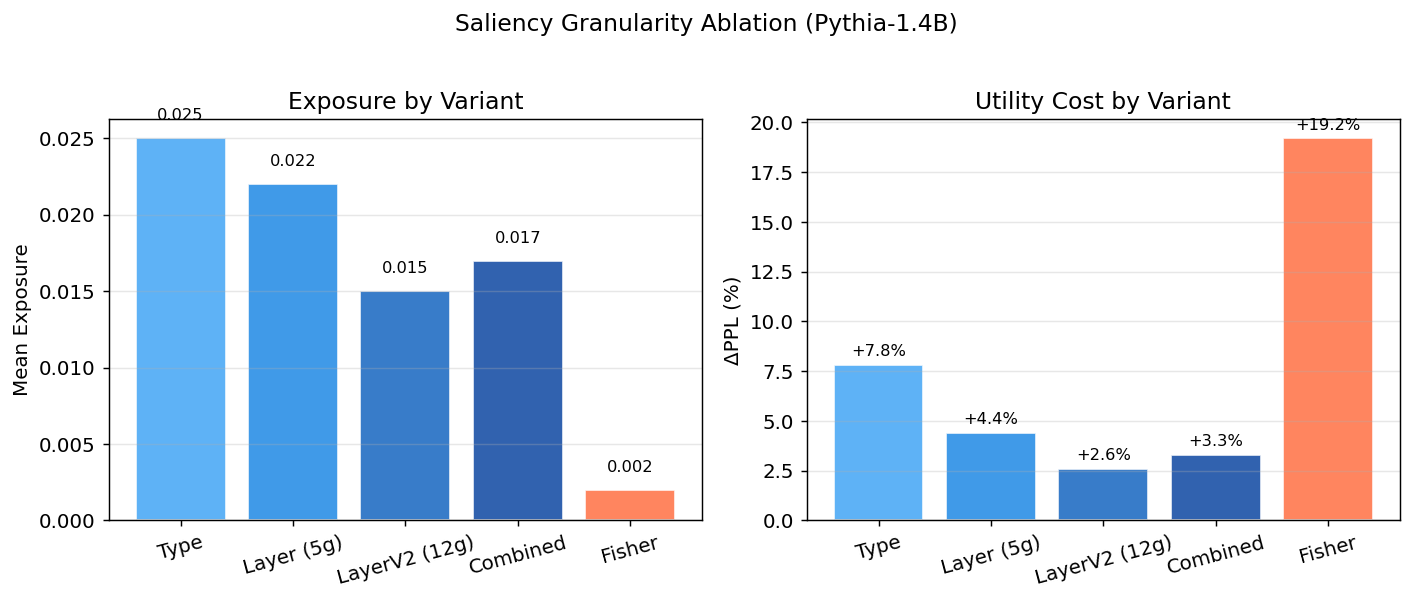

In [5]:
# Table 2: saliency ablation on Pythia-1.4B
ABLATION = [
    {"variant": "Type", "exp": 0.025, "dppl": 7.8},
    {"variant": "Layer (5g)", "exp": 0.022, "dppl": 4.4},
    {"variant": "LayerV2 (12g)", "exp": 0.015, "dppl": 2.6},
    {"variant": "Combined", "exp": 0.017, "dppl": 3.3},
    {"variant": "Fisher", "exp": 0.002, "dppl": 19.2},
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
variants = [r["variant"] for r in ABLATION]
exposures = [r["exp"] for r in ABLATION]
dppls = [r["dppl"] for r in ABLATION]
colors_abl = ["#42a5f5", "#1e88e5", "#1565c0", "#0d47a1", "#ff7043"]
x = np.arange(len(variants))

bars1 = ax1.bar(x, exposures, color=colors_abl, alpha=0.85, edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(variants, rotation=15)
ax1.set_ylabel("Mean Exposure")
ax1.set_title("Exposure by Variant")
ax1.grid(True, axis="y", alpha=0.3)
for bar, val in zip(bars1, exposures):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)

bars2 = ax2.bar(x, dppls, color=colors_abl, alpha=0.85, edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(variants, rotation=15)
ax2.set_ylabel("\u0394PPL (%)")
ax2.set_title("Utility Cost by Variant")
ax2.grid(True, axis="y", alpha=0.3)
for bar, val in zip(bars2, dppls):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"+{val}%", ha="center", va="bottom", fontsize=9)

fig.suptitle("Saliency Granularity Ablation (Pythia-1.4B)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---

## Summary

PSTU achieves 0/175 memorized secrets at every scale with
ΔPPL of +1.3% (1.4B) to +3.2% (6.9B with Trim), while
all five gradient-based baselines fail on 7B+ models.
On the independent LUME benchmark, PSTU removes all memorized PII
on OLMo-1B (+0.9% ΔPPL) and OLMo-7B (−1.7% ΔPPL),
where all baselines either destroy the model or have no effect.
The method runs in 5–17 seconds on a single GPU with no training.

Full paper: *Not All Secrets Are Equal: Type-Aware Unlearning for Language Model Secret Removal*
(ECML PKDD 2026). Source: [hodfa840/ECML](https://github.com/hodfa840/ECML).
